## Figure 4T with Theta. Version 2
Decommisioned, not correct. Do not use.
#### For remote events: For each time bin in each event, find its theta phase and its local posterior.
#### For local events: For each time bin in each event, find its theta phase and its distance to animal.
#### With theta from Corpus Callosum electrodes or MUA
Change%20of%20Mind%20Analysis/figure_single_cell/MakeTheta.ipynb

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from spyglass.shijiegu.changeOfMind_remote_interval import load_remote_animal
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_figures.figure4d import time_to_phase, remote_phase_by_bin, distance_phase_by_bin
from spyglass.shijiegu.Analysis_SGU import ChangeofMindTheta, ChangeofMindRemoteTheta, MUATheta
from spyglass.shijiegu.load import load_run_sessions
from spyglass.shijiegu.changeOfMind import color_by_rat
from spyglass.shijiegu.theta_mua import load_theta_from_calculations

[2026-03-07 13:17:44,623][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[13:17:58][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:17:58][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:17:58][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[13:17:59][WARNING] Spyglass: Deprecation: this class has b

In [4]:
from spyglass.shijiegu.Analysis_SGU import MUAThetaNWB, AnalysisNwbfile
import pynwb

In [5]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}

animal = 'eliot'
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = 'molly'
list_of_days_animals[animal] = ['20220416','20220417','20220418','20220419','20220420']


animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']

animal = "julio"
list_of_days_animals[animal] = ['20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']


animal = "klein"
list_of_days_animals[animal] = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108']

bad_sessions = [] # these sessions have incomplete number of sorted tetrodes

### parameters

In [6]:
decode_name_long = "params_both_max_segment_run_time_2_state"
decode_name_remote = "params_both_max_run_time_2_state"
minimum_duration_long = 0.03
minimum_duration_remote = 0.02
min_posterior = 0.2
sd = 6
proportion = 0.1
hpd = False
output_folder = f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3'

### remote content

In [7]:
for animal in ["lewis"]:
    phase_all = [] #remote theta event
    p_local_all = []
    sessions = []
    
    for d in ["20240108","20240109"]:#list_of_days_animals[animal]:
        nwb_copy_file_name = f"{animal}{d}_.nwb"
        run_session_ids, run_session_names, pos_session_names = load_run_sessions(nwb_copy_file_name)
        for session_name in run_session_names:
            if (animal, d, session_name) in bad_sessions:
                continue

            phase, p_local = remote_phase_by_bin(nwb_copy_file_name, session_name,
                                                  decode_name_remote, minimum_duration_remote, proportion = proportion,
                                                  min_posterior = min_posterior, 
                                                  long_flag = False, data_type = "mua")
            phase_all += phase
            p_local_all += p_local
            
            sessions.append((animal,d, session_name))
            

    # save data
    data = {"phase_all": phase_all, "p_local_all": p_local_all,
            "sessions": sessions
           }
    data_filename = f"remote_content_{animal}_phase_version2.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {output_path}")
    

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
lewis20240108_ 1         01_Rev2Sleep1  pos 0 valid ti
lewis20240108_ 2         02_Rev2Session pos 1 valid ti
lewis20240108_ 3         03_Rev2Sleep2  pos 2 valid ti
lewis20240108_ 4         04_Rev2Session pos 3 valid ti
lewis20240108_ 5         05_Rev2Sleep3  pos 4 valid ti
lewis20240108_ 6         06_Rev2Session pos 5 valid ti
lewis20240108_ 7         07_Rev2Sleep4  pos 6 valid ti
lewis20240108_ 8         08_Rev2Session pos 7 valid ti
lewis20240108_ 9         09_Rev2Sleep5  pos 8 valid ti
 (Total: 9)

arm_track_segment 6
arm_track_segment 9
arm_track_segment 9
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 8
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
arm_track_segment 6
ar

### local content

In [30]:
for animal in ["molly","lewis","julio","klein","eliot"]:
    phase_all = [] #remote theta event
    p_local_all = []
    sessions = []
    
    for d in list_of_days_animals[animal]:
        nwb_copy_file_name = f"{animal}{d}_.nwb"
        run_session_ids, run_session_names, pos_session_names = load_run_sessions(nwb_copy_file_name)
        for session_name in run_session_names:
            if (animal, d, session_name) in bad_sessions:
                continue

            phase, p_local = distance_phase_by_bin(
                nwb_copy_file_name, session_name, decode_name_long, minimum_duration_long,
                 proportion = 0.1,
                 sd = sd, hpd = hpd,
                 data_type = "mua")
            phase_all += phase
            p_local_all += p_local
            
            sessions.append((animal,d, session_name))
            

    # save data
    data = {"phase_all": phase_all, "distance_all": p_local_all,
            "sessions": sessions
           }
    data_filename = f"local_content_{animal}_phase_version2.pkl"
    output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
    with open(output_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {output_path}")

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
molly20220416_ 1         01_Seq2Sleep1  pos 0 valid ti
molly20220416_ 2         02_Seq2Session pos 1 valid ti
molly20220416_ 3         03_Seq2Sleep2  pos 2 valid ti
molly20220416_ 4         04_Seq2Session pos 3 valid ti
molly20220416_ 5         05_Seq2Sleep3  pos 4 valid ti
molly20220416_ 6         06_Seq2Session pos 5 valid ti
molly20220416_ 7         07_Seq2Sleep4  pos 6 valid ti
molly20220416_ 8         08_Seq2Session pos 7 valid ti
molly20220416_ 9         09_Seq2Sleep5  pos 8 valid ti
molly20220416_ 10        10_Seq2Session pos 9 valid ti
molly20220416_ 11        11_Seq2Sleep6  pos 10 valid t
 (Total: 11)

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
molly20220417_ 1         01_Seq2Sleep1  pos 0 valid ti
molly20220417_ 2         02_Seq2Session pos 1 valid ti
molly20220417_ 3         03_Seq2Sleep2  pos 2 valid

In [6]:
def plot_polar_hist(bin_centers, hist_counts, ax, animal):

    color = color_by_rat[animal.lower()]
    
    bin_centers, hist_counts = upsample_polar(bin_centers, hist_counts)
    ax.plot(bin_centers, hist_counts, color=color_by_rat[animal], linewidth = 3, alpha = 0.5)
    
    #ax.bar(bin_centers, hist_counts, width=bar_width, color=color, alpha = 0.5, edgecolor='none')
    #ax.fill(bin_centers, hist_counts, facecolor=color_by_rat[animal], alpha=0.3)

### Plotting

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, Akima1DInterpolator

def upsample_polar(theta, r):

    # Convert to Cartesian
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    # 2. Interpolate in Cartesian space
    # Ensure the curve closes smoothly by appending the start point to the end
    x = np.append(x, x[0])
    y = np.append(y, y[0])
    t = np.linspace(0, 1, len(x)) # Parameter t
    t_smooth = np.linspace(0, 1, 300) # Finer parameter t for smoothness
    
    cs_x = Akima1DInterpolator(t, x)
    cs_y = Akima1DInterpolator(t, y)
    
    x_smooth = cs_x(t_smooth)
    y_smooth = cs_y(t_smooth)
    
    # 3. Convert back to polar
    r_smooth = np.sqrt(x_smooth**2 + y_smooth**2)
    theta_smooth = np.arctan2(y_smooth, x_smooth)
    return theta_smooth, r_smooth

In [8]:
#mean_plocal

In [29]:
animal = 'lewis'

"""remote content"""
data_filename = f"remote_content_{animal}_phase_version2.pkl"
output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
with open(output_path, 'rb') as file:
    data = pickle.load(file)
print(f"Data loaded from {output_path}")

sessions = data["sessions"]

phase_all = data["phase_all"]
p_local_all = np.array(data["p_local_all"])
#p_local_all = 1-p_local_all

bins = np.arange(0, 2*np.pi, 0.1)
bin_ind = np.digitize(phase_all, bins)
mean_plocal = np.array([np.nanmedian(p_local_all[bin_ind == ind]) for ind in range(len(bins)-1)])
mean_plocal[np.isnan(mean_plocal)] = 0
mean_plocal = 1 - mean_plocal

"""local content"""
data_filename = f"local_content_{animal}_phase_version2.pkl"
output_path = os.path.join(output_folder,data_filename) #os.join(output_folder,plot_data_filename)
with open(output_path, 'rb') as file:
    data = pickle.load(file)
print(f"Data loaded from {output_path}")

sessions = data["sessions"]

phase_all = data["phase_all"]
distance_all = np.array(data["distance_all"])

bins = np.arange(0, 2*np.pi, 0.5)
bin_ind = np.digitize(phase_all, bins)
mean_distance = np.array([np.nanmean(distance_all[bin_ind == ind]) for ind in range(len(bins)-1)])
mean_distance[np.isnan(mean_distance)] = 0

Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3/remote_content_lewis_phase_version2.pkl
Data loaded from /home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure3/local_content_lewis_phase_version2.pkl


ValueError: operands could not be broadcast together with shapes (62,) (12,) 

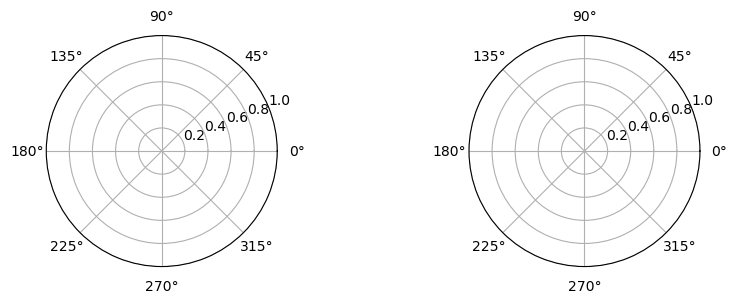

In [31]:
fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize = (10,3))

#### 1. Onset
ax = axes[0]
plot_polar_hist(bins[:-1], mean_plocal, ax, animal)


ax.set_title(f'Rat {animal[0].upper()} \n Average of p(remote)', va='bottom')
ax.grid(True)
ax.set_ylim([0,1])

ax = axes[1]
plot_polar_hist(bins[:-1], mean_distance, ax, animal)


ax.set_title(f'Rat {animal[0].upper()} \n Average of distance(max decode - actual)', va='bottom')
ax.grid(True)
ax.set_ylim([10,100])


# 6. Display the plot
plt.savefig(f'/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/theta_phase_version2_{animal}_muatheta.pdf',dpi=300,bbox_inches='tight')

### End here